In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
crossfit_df = pd.read_csv("df_games_conso.csv")
crossfit_df.head()

,competitorId,competitorName,firstName,lastName,status,gender,countryOfOriginCode,countryOfOriginName,regionId,regionName,affiliateId,affiliateName,age,height,weight,overallRank,overallScore,genderId,year
0,164070,James Fitzgerald,James,Fitzgerald,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,33,69 in,176 lb,1,272,1,2007
1,57785,Brett Marshall,Brett,Marshall,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,33,168 cm,155 lb,2,270,1,2007
2,10091,Josh Everett,Josh,Everett,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,32,69 in,185 lb,3,267,1,2007
3,27065,Chris Spealler,Chris,Spealler,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,28,65 in,143 lb,4,261,1,2007
4,7173,Breck Berry,Breck,Berry,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,31,67 in,170 lb,5,252,1,2007


In [3]:
crossfit_df.columns.tolist()

['competitorId',
 'competitorName',
 'firstName',
 'lastName',
 'status',
 'gender',
 'countryOfOriginCode',
 'countryOfOriginName',
 'regionId',
 'regionName',
 'affiliateId',
 'affiliateName',
 'age',
 'height',
 'weight',
 'overallRank',
 'overallScore',
 'genderId',
 'year']

In [4]:
crossfit_df[['age', 'height', 'weight', 'overallScore']].info(
)

<class 'pandas.DataFrame'>
RangeIndex: 1714 entries, 0 to 1713
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           1714 non-null   int64
 1   height        1545 non-null   str  
 2   weight        1550 non-null   str  
 3   overallScore  1714 non-null   str  
dtypes: int64(1), str(3)
memory usage: 53.7 KB


In [5]:
crossfit_df[['height', 'weight','overallScore']].head(10)

,height,weight,overallScore
0,69 in,176 lb,272
1,168 cm,155 lb,270
2,69 in,185 lb,267
3,65 in,143 lb,261
4,67 in,170 lb,252
5,NaN,205 lb,248
6,72 in,185 lb,243
7,NaN,NaN,239
8,NaN,NaN,235
9,71 in,193 lb,232


In [6]:
crossfit_df['overallScore']= pd.to_numeric(
    crossfit_df['overallScore'], errors='coerce'
)
crossfit_df['overallScore'].head(10)

0    272.0
1    270.0
2    267.0
3    261.0
4    252.0
5    248.0
6    243.0
7    239.0
8    235.0
9    232.0
Name: overallScore, dtype: float64

In [7]:
crossfit_df['height_cm'] = crossfit_df['height']
mask_in = crossfit_df['height'].str.contains('in', na=False)
mask_cm = crossfit_df['height'].str.contains('cm', na=False)
crossfit_df.loc[mask_in, 'height_cm']=(
    crossfit_df.loc[mask_in,'height']
    .str.replace('in', '', regex=False)
    .str.strip()
    .astype(float)*2.54
)
crossfit_df.loc[mask_cm, 'height_cm']=(
    crossfit_df.loc[mask_cm,'height']
    .str.replace('cm', '', regex=False)
    .str.strip()
    .astype(float)
)
crossfit_df['height_cm'] = pd.to_numeric(

crossfit_df['height_cm'],
errors='coerce'
)
crossfit_df[['height', 'height_cm']].head(10)

TypeError: Invalid value for dtype 'str'. Value should be a string or missing value (or array of those).

In [12]:
def convert_height(value):
    if pd.isna(value):
        return None
    value = str(value)
    if "cm" in value:
        return float(value.replace(" cm", ""))
    elif "in" in value:
        return float(value.replace(" in", "")) * 2.54
    return None

In [13]:
convert_height(crossfit_df["height"].iloc[0])

175.26

In [14]:
crossfit_df['height_cm'] = crossfit_df['height'].apply(convert_height)
crossfit_df[['height', 'height_cm']].head(10)

,height,height_cm
0,69 in,175.26
1,168 cm,168.00
2,69 in,175.26
3,65 in,165.10
4,67 in,170.18
5,NaN,NaN
6,72 in,182.88
7,NaN,NaN
8,NaN,NaN
9,71 in,180.34


In [10]:
crossfit_df["weight_kg"] = ( crossfit_df["weight"].astype("string").str.replace(" lb" , "", regex=False))
crossfit_df["weight_kg"] = pd.to_numeric(crossfit_df["weight_kg"],errors="coerce") * 0.453592
crossfit_df[["weight", "weight_kg"]].head(10)

,weight,weight_kg
0,176 lb,79.832192
1,155 lb,70.30676
2,185 lb,83.91452
3,143 lb,64.863656
4,170 lb,77.11064
5,205 lb,92.98636
6,185 lb,83.91452
7,NaN,<NA>
8,NaN,<NA>
9,193 lb,87.543256


In [20]:
model_df=crossfit_df[['age', 'height_cm', 'weight_kg', 'overallScore']].dropna()
model_df.shape

(1118, 4)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
x=model_df[['age', 'height_cm', 'weight_kg']]
y=model_df['overallScore']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((894, 3), (224, 3))

In [ ]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 554.9 kB/s  0:00:18 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred[:5]

array([425.64486038, 417.77961259, 357.47703006, 368.11994043,
       351.23760576])

In [24]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

MSE: 82971.85861106109
R2: -0.00022834276717431656


In [26]:
residuals = y_test - y_pred
residuals.head()

1517    569.355140
316    -284.779613
779     429.522970
1036    185.880060
1115    280.762394
Name: overallScore, dtype: float64

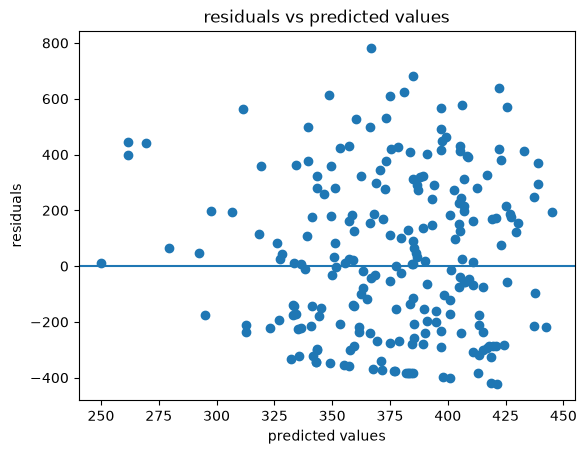

In [27]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("predicted values")
plt.ylabel("residuals")
plt.title("residuals vs predicted values")
plt.show()

### residual analysis 
the residuals are spread around zero but the spread is quite large.
there is no clear linear pattern but the variance is not completley constant across all predicted values.
this suggests that the linear regresstion model does not explain the overall score very well using only age height and weight

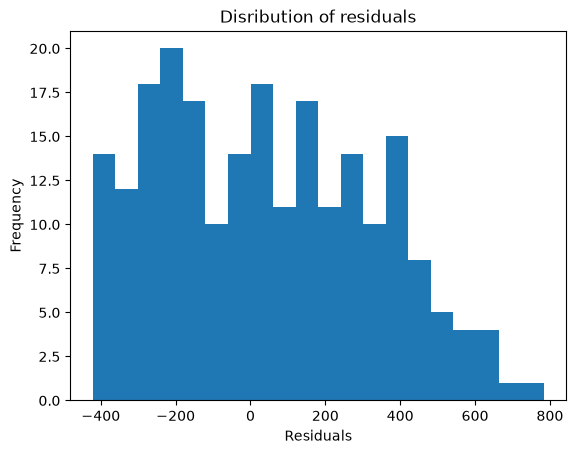

In [31]:
plt.hist(residuals, bins = 20)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Disribution of residuals")
plt.show()

### RESIDUAL DISTRIBUTION
the residuals are widely spread and are not perfectly symmetric around zero. 
the distribution has a longer posetive tail  wich suggests that the model understimates the overall score for some competitors.
this indicates that age height and weight alone are not sufficioent toaccurately predict over all score.

In [ ]:
absolute_errors = np.abs(residuals)


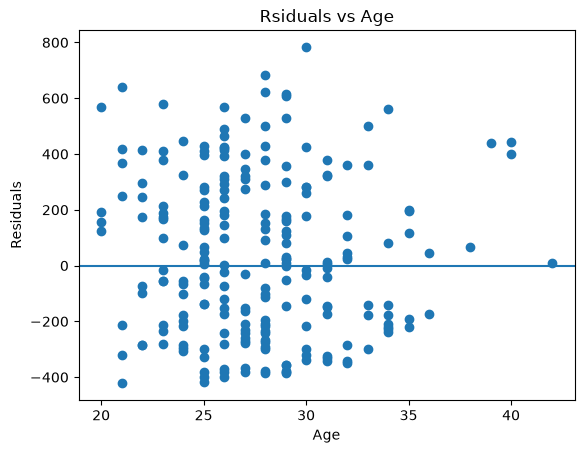

In [32]:
plt.scatter(x_test['age'], residuals)
plt.axhline(y=0)
plt.xlabel("Age")
plt.ylabel("Residuals")
plt.title("Rsiduals vs Age")
plt.show()

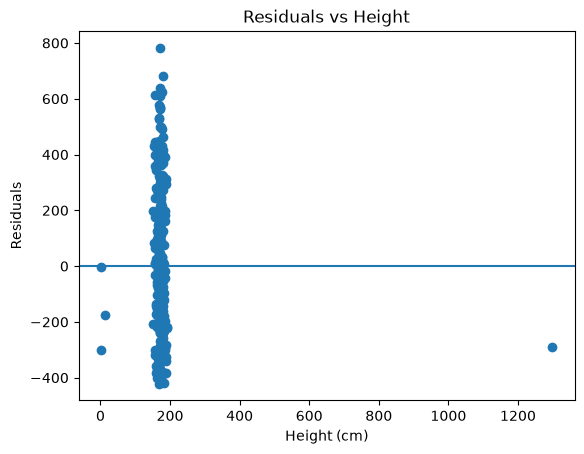

In [33]:
plt.scatter(x_test['height_cm'], residuals)
plt.axhline(y=0)
plt.xlabel("Height (cm)")
plt.ylabel("Residuals")
plt.title("Residuals vs Height")
plt.show()

In [36]:
crossfit_df[crossfit_df['height_cm']>250][['height', 'height_cm', 'overallScore']]

,height,height_cm,overallScore
285,511 in,1297.94,106.0
1373,156 in,396.24,0.0


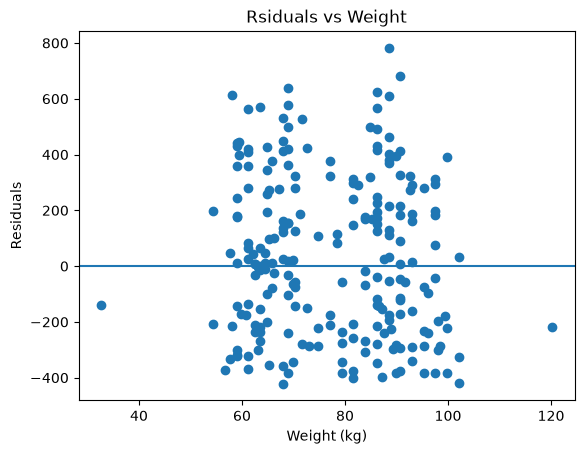

In [34]:
plt.scatter(x_test['weight_kg'], residuals)
plt.axhline(y=0)
plt.xlabel("Weight (kg)")
plt.ylabel("Residuals")
plt.title("Rsiduals vs Weight")
plt.show()

### 1.3 PATTERNS OF EXTREME ERRORS

In [37]:
error_df = x_test.copy()
error_df['actual'] = y_test
error_df['predicted'] = y_pred
error_df['residuals'] = residuals
error_df['absolute_error'] = np.abs(residuals)
error_df.sort_values('absolute_error', ascending=False).head(5)

,age,height_cm,weight_kg,actual,predicted,residuals,absolute_error
1413,30,170.18,88.45044,1150.0,366.867928,783.132072,783.132072
1555,28,179.00,90.7184,1068.0,384.928292,683.071708,683.071708
597,21,170.00,68.945984,1062.0,422.294109,639.705891,639.705891
1476,28,178.00,86.18248,1004.0,381.028997,622.971003,622.971003
600,29,157.48,58.059776,964.0,348.704989,615.295011,615.295011


### patterns of extreme errors
the five largest error are all cases where the model strongly understimates the actual overall score
the competitors have realistic age weight and heightvalues so these errors do not appear to be caused by obvious data quality problems.
instead the large errors suggest a limitation of the model: age height and weight alone are not enough to explain competetive performance
important factors such as training  streenght endurance 

In [38]:
threshold = error_df['absolute_error'].quantile(0.95)
extreme_errors = error_df[error_df['absolute_error']>= threshold].sort_values('absolute_error', ascending=False)
extreme_errors

,age,height_cm,weight_kg,actual,predicted,residuals,absolute_error
1413,30,170.18,88.45044,1150.0,366.867928,783.132072,783.132072
1555,28,179.00,90.7184,1068.0,384.928292,683.071708,683.071708
597,21,170.00,68.945984,1062.0,422.294109,639.705891,639.705891
1476,28,178.00,86.18248,1004.0,381.028997,622.971003,622.971003
600,29,157.48,58.059776,964.0,348.704989,615.295011,615.295011
1138,29,170.18,88.45044,984.0,374.885198,609.114802,609.114802
939,23,169.00,68.945984,984.0,406.250414,577.749586,577.749586
1517,20,170.18,63.50288,995.0,425.644860,569.355140,569.355140
1478,26,171.00,86.18248,965.0,396.999445,568.000555,568.000555
942,34,170.00,61.23492,874.0,311.456371,562.543629,562.543629


###analysis of extreme errors
the top 5% largest absolute errors contain 12 observation
in all of these cases the residuals. are large and posetive meaning that the model strongly understimates the actual overallscore.
most of the competitors in these observations have realistic age weight and height therfore the extreme errors do not appear to be mainly caused by obvious data quality issues


### 1.4 statisticl propreties

In [42]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis
mae = mean_absolute_error(y_test, y_pred)
std_residuals = np.std(residuals)
skewness = skew(residuals)
kurt = kurtosis(residuals)
print("MAE:", mae)
print("standart deviation of residuals:", std_residuals)
print("skewness:", skewness)
print("kurtosis:", kurt)


MAE: 243.00403520618053
standart deviation of residuals: 285.4670826332071
skewness: 0.28856463525093395
kurtosis: -0.911312543613688


### 
the errors are relatively large, with an MAE of about 243.
the residuals show only a slight positive skew and the negative kurtosis indicates  a relatively flat distribution.

## 2 

In [44]:
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train, y_train)
tree_pred = tree_model.predict(x_test)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse=np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree RMSE", tree_rmse)
print("Decision Tree R2:", tree_r2)

Decision Tree MSE: 140870.37152777778
Decision Tree RMSE 375.3270194480778
Decision Tree R2: -0.6981967213572988


In [46]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2=r2_score(y_test, rf_pred)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)


Random Forest MSE: 88233.70059313222
Random Forest RMSE: 297.04158057944045
Random Forest R2: -0.0636600119346784


In [50]:
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)
results = pd.DataFrame({'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
                        'MSE': [lr_mse, tree_mse, rf_mse], 
                        'RMSE': [lr_rmse, tree_rmse, rf_rmse], 'R2': [lr_r2, tree_r2, rf_r2]})
results

,Model,MSE,RMSE,R2
0,Linear Regression,82971.858611,288.048362,-0.000228
1,Decision Tree,140870.371528,375.327019,-0.698197
2,Random Forest,88233.700593,297.041581,-0.063660


### model comparison
linear regression performed best with the lowest RMSE and r2 value closest to zero
random forest performed slightly worse while decision tree had the weakest results
overall all models shwed limited predictive ability 


### 3 classificationberror analysis 
## 3.1 confusion matrix analysis

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
threshold = crossfit_df['overallScore'].quantile(0.25)
crossfit_df['top25'] = (crossfit_df['overallScore']<= threshold).astype(int)
classification_df = crossfit_df[['age', 'weight', 'height', 'top25']].copy()
classification_df['age'] = pd.to_numeric(
    classification_df['age'],
    errors='coerce'
)
classification_df['height'] = pd.to_numeric(
    classification_df['height'],
    errors='coerce'
)
classification_df['weight'] = pd.to_numeric(
    classification_df['weight'],
    errors='coerce'
)
print(classification_df[['age', 'weight', 'height']].head(10))
print(classification_df[['age','weight', 'height']])
      
classification_df = classification_df.dropna()
x = classification_df[['age', 'height', 'weight', ]]
y = classification_df['top25']
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
x,
y,
test_size = 0.2,
random_state=42,
stratify = y)
clf = LogisticRegression(max_iter = 1000)
clf.fit(x_train_c , y_train_c)
y_pred_c = clf.predict(x_test_c)
print(y_test_c.value_counts())




   age  weight  height
0   33     NaN     NaN
1   33     NaN     NaN
2   32     NaN     NaN
3   28     NaN     NaN
4   31     NaN     NaN
5   25     NaN     NaN
6   30     NaN     NaN
7    0     NaN     NaN
8    0     NaN     NaN
9   21     NaN     NaN
      age  weight  height
0      33     NaN     NaN
1      33     NaN     NaN
2      32     NaN     NaN
3      28     NaN     NaN
4      31     NaN     NaN
...   ...     ...     ...
1709   19     NaN     NaN
1710   18     NaN     NaN
1711   27     NaN     NaN
1712   24     NaN     NaN
1713   25     NaN     NaN

[1714 rows x 3 columns]


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [72]:
print(crossfit_df[['age', 'height', 'weight']].head(15))

    age  height  weight
0    33   69 in  176 lb
1    33  168 cm  155 lb
2    32   69 in  185 lb
3    28   65 in  143 lb
4    31   67 in  170 lb
5    25     NaN  205 lb
6    30   72 in  185 lb
7     0     NaN     NaN
8     0     NaN     NaN
9    21   71 in  193 lb
10   20   70 in  183 lb
11   37   66 in  190 lb
12   42   68 in  190 lb
13   24   75 in  265 lb
14   24     NaN     NaN


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

df = crossfit_df[['age', 'overallScore',]].copy()
df['age']=pd.to_numeric(df['age'], errors = 'coerce')
df['overallScore']=pd.to_numeric(df['overallScore'], errors='coerce')
df=df.dropna()
threshold = df['overallScore'].quantile(0.25)
df['top25']= (df['overallScore']<=threshold).astype(int)
x=df[['age']]
y=df[['top25']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

model=LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[ :1]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[[234   0]
 [ 78   0]]


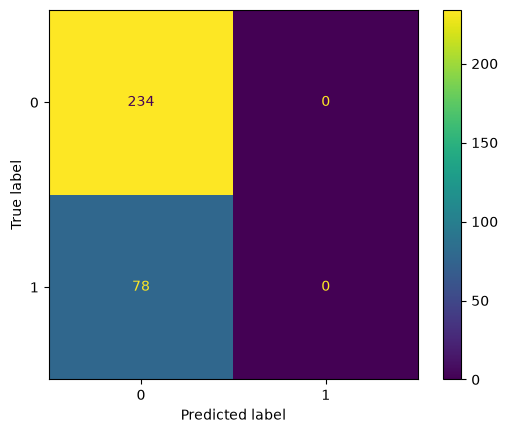

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(cm).plot()

### confusion matrix analysis 
the confusion matrix show 234 true negative  0 false positive 78 false negative and 0 true positive.
the model predict all athlets as not belonging to the top 25%
therefore the most critical error is the false negative
this indicates that age alone is not sufficient to distinguish top preforming athlets

In [81]:
import numpy as np
correct = (y_pred == y_test.values.ravel())
confidence = np.maximum(y_prob, 1-y_prob)
print("man confidence - correct:", confiedence[correct].mean())
print("man confidence - incorrect:", confiedence[~correct].mean())
high_errors = (~correct)&(confidence >= 0.8)
print("high-confidence errors:", high_errors.sum())

NameError: name 'confiedence' is not defined

correct
False    28.448718
True     26.376068
Name: age, dtype: float64


TypeError: Axes.boxplot() got an unexpected keyword argument 'colunm'

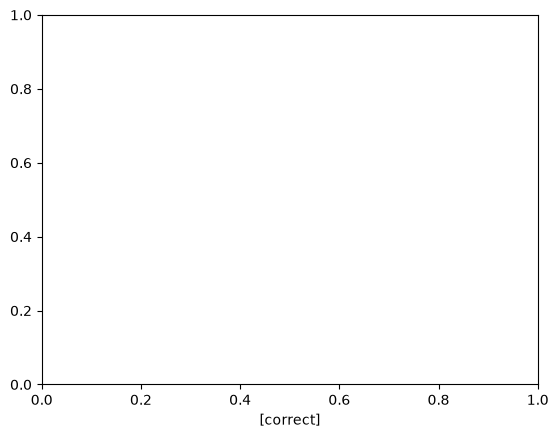

In [84]:
result = x_test.copy()
result['correct'] = (y_pred == y_test.values.ravel())
print(result.groupby('correct')['age'].mean())
result.boxplot(colunm='age', by='correct')

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

classification_df = crossfit_df[['age', 'top25']].copy()
classification_df['age'] = pd.to_numeric(
    classification_df['age'],
    errors = 'coerce'
)
classification_df = classification_df.dropna()
x = classification_df[['age']]
y = classification_df['top25'].astype(int)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.3,
    random_state = 42
)
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]
correct = (y_pred == y_test.to_numpy())
conf = np.maximum(y_prob, 1 - y_prob)
print("Correct:", conf[correct].mean())
print("Incorrect:", conf[~correct].mean())
print("Hight-confidence errors:", ((~correct)& (conf >= 0.8)).sum())

Correct: 0.782562581302336
Incorrect: 0.7785363173603724
Hight-confidence errors: 29


## 3.2 
the model shows similier confiedence for correct and incorrect predections.
it also makes 29 hight confiedence errors indicating that its predict probabilities are not very reliable/

In [98]:
error_df = x_test.copy()
error_df['correct']=(
y_pred == y_test.to_numpy()

)
print(error_df.groupby('correct')['age'].describe())

         count       mean       std  min   25%   50%   75%   max
correct                                                         
False    132.0  27.424242  5.733418  0.0  25.0  27.5  30.0  41.0
True     383.0  26.608355  7.550052  0.0  25.0  27.0  30.0  54.0


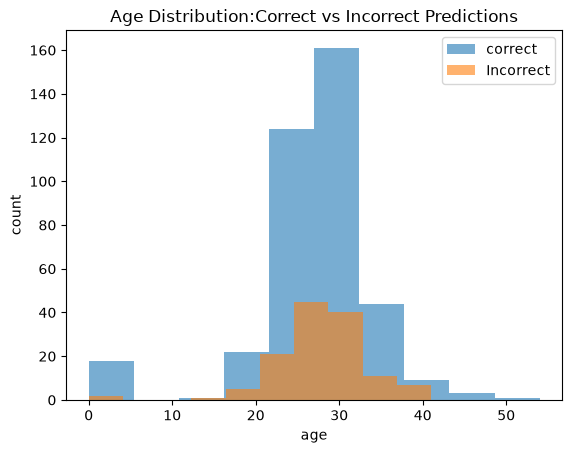

In [100]:
import matplotlib.pyplot as plt
plt.hist(
    error_df[error_df['correct'] == True]['age'],
    alpha = 0.6,
    label = 'correct'
)
plt.hist(
    error_df[error_df['correct'] == False]['age'],
    alpha = 0.6,
    label = 'Incorrect'
)
plt.xlabel('age')
plt.ylabel('count')
plt.title('Age Distribution:Correct vs Incorrect Predictions')
plt.legend()
plt.show()

correct and incorrect predections show substantial overlap across age group
most errors occur in the same age range as most athles uggesting that age alone is not sufficiant to clearly distnguish top25% athlets

In [101]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score
)
import numpy as np
import pandas as pd
actual = np.asarray(y_test).ravel()

In [104]:
rows = []
for threshold in np.arange(0.1, 1.0, 0.1):
    prediction = (y_prob >= threshold).astype(int)
    rows.append([
        round(threshold, 1),
        precision_score(actual, prediction, zero_division=0),
        recall_score(actual, prediction, zero_division=0),
        f1_score(actual, prediction, zero_division=0),
        fbeta_score(actual, prediction, beta=2, zero_division=0),
        matthews_corrcoef(actual, prediction)
    ])
    results = pd.DataFrame(
        rows,
        columns=[
            'Threshold',
            'Precision',
            'Recall',
            'F1',
            'F-beta',
            'MCC'
        ]
    )
    results

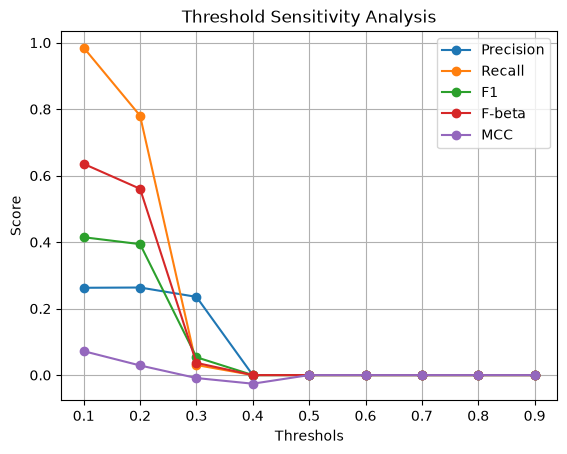

In [108]:
import matplotlib.pyplot as plt
plt.plot(results['Threshold'], results['Precision'], marker = 'o', label='Precision')
plt.plot(results['Threshold'], results['Recall'], marker = 'o', label='Recall')
plt.plot(results['Threshold'], results['F1'], marker = 'o', label='F1')
plt.plot(results['Threshold'], results['F-beta'], marker = 'o', label='F-beta')
plt.plot(results['Threshold'], results['MCC'], marker = 'o', label='MCC')
plt.xlabel('Threshols')
plt.ylabel('Score')
plt.title('Threshold Sensitivity Analysis')
plt.legend()
plt.grid()
plt.show()

### threshold sensitivity analysis 
lower threshold provide higher recall, whike precision remains relatively loow
at thresholds above 0.3 the model performance drops significantly 
this suggests that the model has limited ability to distinguish top 25% athletesfrom the others 

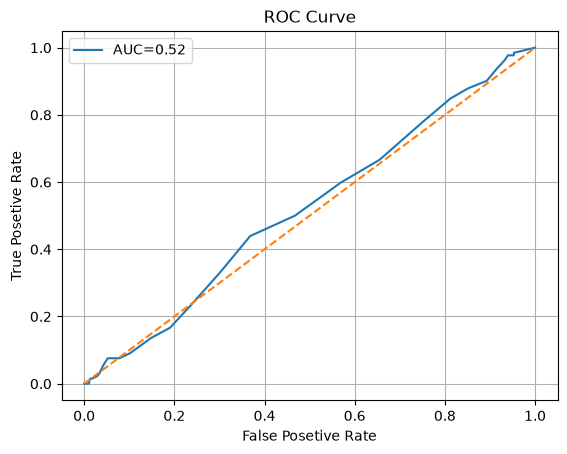

AUC: 0.5206108078170743


In [112]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, threshold = roc_curve(actual, y_prob)
auc_score = roc_auc_score(actual, y_prob)

plt.plot(fpr, tpr, label = f'AUC={auc_score:.2f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Posetive Rate')
plt.ylabel('True Posetive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()
print("AUC:", auc_score)

## ROC and auc
THE ROC curve is close to the diagnal line and the auc is 0.52
this indicates that the model has very weak ability distinguish top 25% athletes from the others

### 3.5 Discussin 
the classification model shoed weak performance is identifying top 25% athletes.
age alone was not sufficient to clearly separate high performing athletes from the others,  the threshold analysis also showed model performance change significantly depending on the selected threshold
the roc - auc score of 0.52 indicates that the model performs only slightly better than random guessing


### 4 final reflaction
the main challenge in this project was that the available features had limited predective power
the regression models showed relatively largeprediction errors and the classification model had difficulty identifying top 25%athletes
the results suggest that age height and weightalone are not enough to accurately predict crossfit performance